# epsilon_data — worked examples
Five real tasks, each a few lines through the **public** loader, each ending in a plot. If any of these is awkward to write, the API is wrong (fix the API, not the notebook).

In [1]:
# make epsilon_data importable no matter where this notebook is opened from
import sys, pathlib
here = pathlib.Path.cwd()
root = next((p for p in [here, *here.parents] if (p / 'epsilon_data').is_dir()), here.parent)
sys.path.insert(0, str(root))
import matplotlib.pyplot as plt   # inline backend under Jupyter captures the figures
import epsilon_data as ed
print('epsilon_data', ed.__version__, '| root', root)

epsilon_data 1.0 | root C:\Users\alvar\Projects\Epsilon Fund\Epsilon-Quant-Research\polymarket\research


## 1 — Find the busiest politics markets and open one

In [2]:
cat = ed.catalog(universe='politics_negrisk', min_trades=1)
top = cat.sort_values('n_trades', ascending=False).head(10)
print(top[['question','outcome_label','n_trades','median_spread_cents','path']].to_string(index=False))
ref = top.iloc[0]['path']          # open the busiest
print('\nopening:', ref)

                                                                        question outcome_label  n_trades  median_spread_cents                                                                                                                                  path
      Will there be no change in Fed interest rates after the July 2026 meeting?           Yes     26419                  0.6               politics_negrisk/fed-decision-in-july-181/will-there-be-no-change-in-fed-interest-rates-after-the-july-2026-meeting/Yes
Will the Fed decrease interest rates by 25 bps after the September 2026 meeting?            No     24955                  0.2 politics_negrisk/fed-decision-in-september-762/will-the-fed-decrease-interest-rates-by-25-bps-after-the-september-2026-meeting-586/No
                     Will Mojtaba Khamenei be head of state in Iran end of 2026?           Yes     24568                  0.5                               politics_negrisk/iran-leader-end-of-2026/will-mojtaba-khamenei-b

## 2 — Plot a market's mid and spread across its life

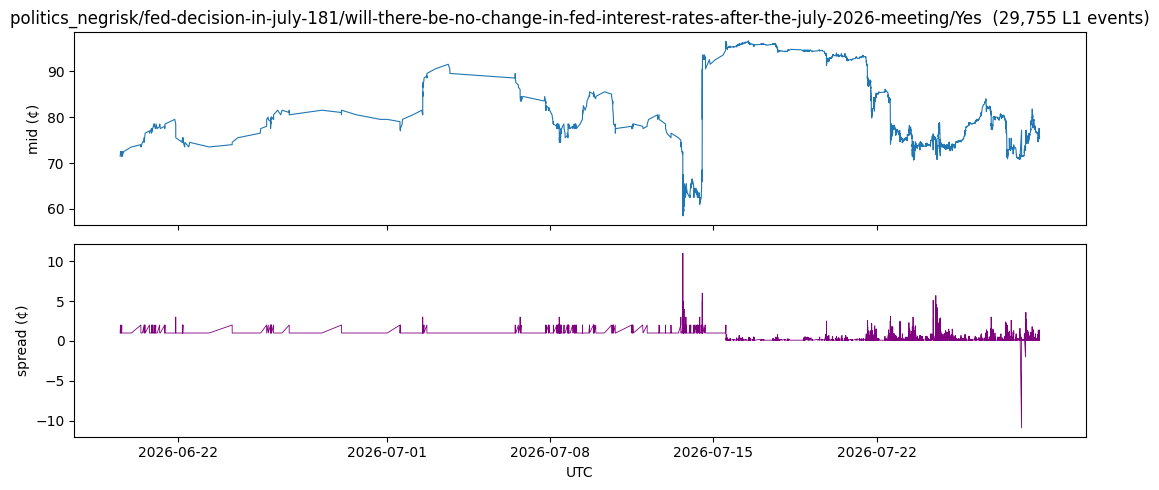

In [3]:
l1 = ed.load_l1(ref)
fig, (a0, a1) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
a0.plot(l1['ts'], l1['mid']*100, lw=0.8); a0.set_ylabel('mid (¢)')
a1.plot(l1['ts'], l1['spread_c'], lw=0.6, color='purple'); a1.set_ylabel('spread (¢)')
a0.set_title(f'{ref}  ({len(l1):,} L1 events)'); a1.set_xlabel('UTC'); plt.tight_layout(); plt.show()

## 3 — Plot both sides together and confirm they mirror
`load_pair` returns both outcomes' mids on one aligned index; a healthy market sums to ~1.

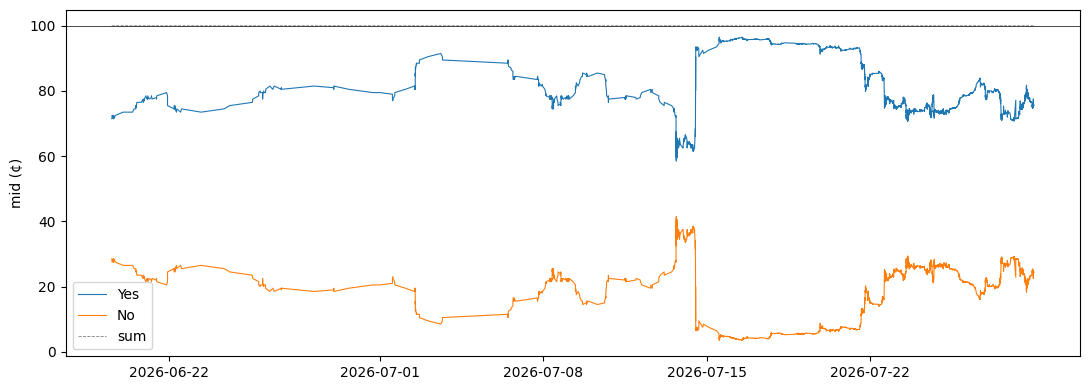

median sum: 1.0


In [4]:
cid = top.iloc[0]['condition_id']
pair = ed.load_pair(cid)
labels = pair.attrs['labels']
fig, ax = plt.subplots(figsize=(11, 4))
for idx in (0, 1):
    ax.plot(pair.index, pair[idx]*100, lw=0.8, label=f'{labels[idx]}')
ax.plot(pair.index, (pair[0]+pair[1])*100, lw=0.6, color='grey', ls='--', label='sum')
ax.axhline(100, color='k', lw=0.5); ax.set_ylabel('mid (¢)'); ax.legend(); plt.tight_layout(); plt.show()
print('median sum:', round(float((pair[0]+pair[1]).median()), 4))

## 4 — Plot every candidate in a NegRisk event and look at the YES sum
Across a politics NegRisk event, the YES mids of all its markets should sum to ~1.

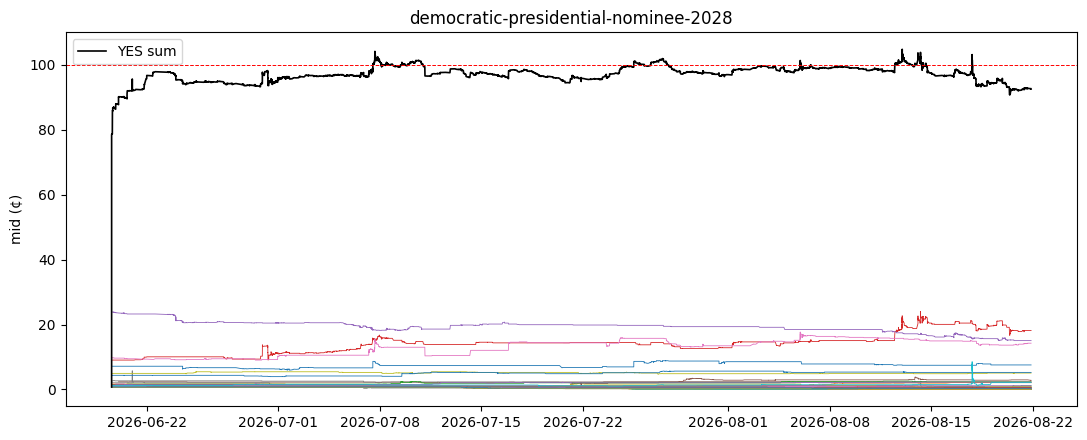

event: democratic-presidential-nominee-2028 | markets: 51 | median YES-sum: 0.982


In [5]:
evs = ed.events(universe='politics_negrisk')
evs = evs[(evs['neg_risk'] == True) & (evs['n_markets'] >= 4)].sort_values('total_trades', ascending=False)
ev_slug = evs.iloc[0]['event_slug']
wide = ed.load_event(ev_slug)
meta = wide.attrs['tokens']
yes_cols = [a for a in wide.columns if meta[a]['outcome'] == 'YES']
fig, ax = plt.subplots(figsize=(11, 4.5))
for a in yes_cols:
    ax.plot(wide.index, wide[a]*100, lw=0.6)
ax.plot(wide.index, wide[yes_cols].sum(axis=1)*100, color='black', lw=1.2, label='YES sum')
ax.axhline(100, color='red', ls='--', lw=0.7); ax.set_title(ev_slug); ax.set_ylabel('mid (¢)'); ax.legend(); plt.tight_layout(); plt.show()
print('event:', ev_slug, '| markets:', len(yes_cols), '| median YES-sum:', round(float(wide[yes_cols].sum(axis=1).median()), 3))

## 5 — Take a resolved market and plot the path into settlement
For a market that converged, the winner walks to 100¢ and the loser to 0¢.

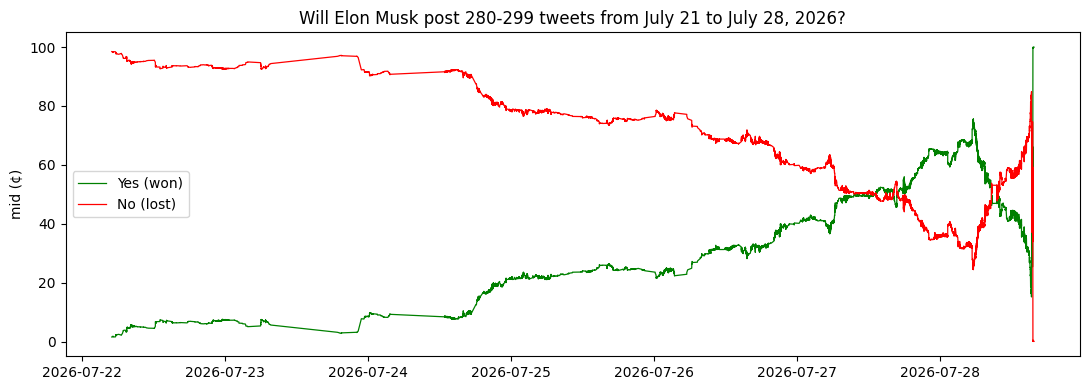

In [6]:
res = ed.catalog(universe='politics_negrisk', resolved=True)
res = res[res['check4_status'] == 'converged_correct'].sort_values('n_l1_events', ascending=False)
rcid = res.iloc[0]['condition_id']
pair = ed.load_pair(rcid); labels = pair.attrs['labels']
won = {i: (res[(res.condition_id==rcid) & (res.outcome_index==i)]['resolved_outcome'].iloc[0] == labels[i]) for i in (0,1)}
fig, ax = plt.subplots(figsize=(11, 4))
for i in (0, 1):
    ax.plot(pair.index, pair[i]*100, lw=0.9, color=('green' if won[i] else 'red'),
            label=f"{labels[i]} ({'won' if won[i] else 'lost'})")
ax.set_ylim(-5, 105); ax.set_ylabel('mid (¢)'); ax.legend(); ax.set_title(res.iloc[0]['question'][:70]); plt.tight_layout(); plt.show()